# Order Parameters

To characterize the orientational organization of elongated cells, the following global order parameters are recorded.

The global nematic order is defined as

\begin{equation}
    Q_{E, elongated}(t)
    =
    \frac{1}{N_e(t)}
    \sqrt{
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \sin\left(2\varphi_i(t)\right)
        \right]^2
        +
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \cos\left(2\varphi_i(t)\right)
        \right]^2
    }.
\end{equation}

The global polar order is defined as

\begin{equation}
    P_{E, elongated}(t)
    =
    \frac{1}{N_e(t)}
    \sqrt{
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \sin\left(\varphi_i(t)\right)
        \right]^2
        +
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \cos\left(\varphi_i(t)\right)
        \right]^2
    }.
\end{equation}

We also calculate the parameters normalized by the total number of cells:

\begin{equation}
    Q_{E, total}(t)
    =
    \frac{1}{N}
    \sqrt{
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \sin\left(2\varphi_i(t)\right)
        \right]^2
        +
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \cos\left(2\varphi_i(t)\right)
        \right]^2
    },
\end{equation}

and 

\begin{equation}
    P_{E, total}(t)
    =
    \frac{1}{N}
    \sqrt{
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \sin\left(\varphi_i(t)\right)
        \right]^2
        +
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \cos\left(\varphi_i(t)\right)
        \right]^2
    }.
\end{equation}

The phenotypic composition is characterized by

\begin{equation}
    f_E(t)
    =
    \frac{N_e(t)}{N}.
\end{equation}

These quantities satisfy

\begin{equation}
    P_{E, total}(t)=f_E(t)P_{E, elongated}(t),
    \qquad
    Q_{E, total}(t)=f_E(t)Q_{E, elongated}(t).
\end{equation}

When $N_e(t)=0$, the order parameters normalized by the elongated population are set to zero.

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## Load and inspect data

We start by loading and inspecting the processed order-parameter data.

In [2]:
# Load order parameters data
DATA_DIR = "data/order_parameters"

order_parameters = pd.read_parquet(
    f"{DATA_DIR}/order_parameters.parquet"
)

# Display the first few rows of the order parameters DataFrame
order_parameters.head()

,N,reference_N,actual_N,rho,actual_rho,seed,step,initial_fraction_elongated,force,nematic,polar,nematic_2,polar_2,fraction_elongated
0,10000,10152,9000,0.8,0.799975,12944511869278,0,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.000000,0.000000,0.000000,0.000000,0.000000
1,10000,10152,9000,0.8,0.799975,12944511869278,100,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.085179,0.097603,0.000303,0.000347,0.003556
2,10000,10152,9000,0.8,0.799975,12944511869278,200,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.087203,0.111714,0.000484,0.000621,0.005556
3,10000,10152,9000,0.8,0.799975,12944511869278,300,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.083131,0.052225,0.000693,0.000435,0.008333
4,10000,10152,9000,0.8,0.799975,12944511869278,400,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.067126,0.066713,0.000850,0.000845,0.012667


In [3]:
# Print the shape of the DataFrame
print("Shape:", order_parameters.shape)

# Print the column names and their data types
print("\nColumns:")
print(order_parameters.columns.tolist())

print("\nDtypes:")
print(order_parameters.dtypes)

Shape: (128256, 14)

Columns:
['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'initial_fraction_elongated', 'force', 'nematic', 'polar', 'nematic_2', 'polar_2', 'fraction_elongated']

Dtypes:
N                               int64
reference_N                     int64
actual_N                        int64
rho                           float64
actual_rho                    float64
seed                            int64
step                            int64
initial_fraction_elongated    float64
force                             str
nematic                       float64
polar                         float64
nematic_2                     float64
polar_2                       float64
fraction_elongated            float64
dtype: object


In [4]:
# Print the unique values of the "N" column
print("N values:")
print(sorted(order_parameters["N"].unique()))

# Print the unique values of the "rho" column
print("\nNumber of seeds by rho:")
display(
    order_parameters
    .groupby("rho")["seed"]
    .nunique()
    .to_frame("n_seeds")
)

N values:
[np.int64(10000)]

Number of seeds by rho:


,n_seeds
rho,
0.80,32
0.81,32
0.82,32
0.83,32
0.84,32
0.85,32
0.86,32
0.87,32


In [5]:
# Verify the range of steps in the order parameters DataFrame
print("Step range:")
print(
    "min =", order_parameters["step"].min(),
    "max =", order_parameters["step"].max(),
)

print(
    "number of unique steps =",
    order_parameters["step"].nunique(),
)

print("\nFirst steps:")
print(
    sorted(order_parameters["step"].unique())[:20]
)

Step range:
min = 0 max = 50000
number of unique steps = 501

First steps:
[np.int64(0), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1100), np.int64(1200), np.int64(1300), np.int64(1400), np.int64(1500), np.int64(1600), np.int64(1700), np.int64(1800), np.int64(1900)]


In [6]:
# Summarize the coverage of steps for each combination of rho and seed
coverage = (
    order_parameters
    .groupby(["rho", "seed"])["step"]
    .agg(["min", "max", "nunique"])
)

display(
    coverage
    .groupby("rho")
    .agg(["min", "max"])
)

min        max        nunique     
     min max    min    max     min  max
rho                                    
0.80   0   0  50000  50000     501  501
0.81   0   0  50000  50000     501  501
0.82   0   0  50000  50000     501  501
0.83   0   0  50000  50000     501  501
0.84   0   0  50000  50000     501  501
0.85   0   0  50000  50000     501  501
0.86   0   0  50000  50000     501  501
0.87   0   0  50000  50000     501  501

In [7]:
# Check for duplicates in the order parameters DataFrame
n_duplicates = order_parameters.duplicated(
    ["N", "rho", "seed", "step"]
).sum()

print("Duplicated (N, rho, seed, step):", n_duplicates)

Duplicated (N, rho, seed, step): 0


In [8]:
# Check for missing values in the order parameters DataFrame
display(
    order_parameters.isna().sum().to_frame("n_nan")
)

,n_nan
N,0
reference_N,0
actual_N,0
rho,0
actual_rho,0
seed,0
step,0
initial_fraction_elongated,0
force,0
nematic,0


In [9]:
# Verify the identities polar_2 = f_E * polar and nematic_2 = f_E * nematic
polar_identity = np.allclose(
    order_parameters["polar_2"],
    order_parameters["fraction_elongated"]
    * order_parameters["polar"],
    equal_nan=True,
)

nematic_identity = np.allclose(
    order_parameters["nematic_2"],
    order_parameters["fraction_elongated"]
    * order_parameters["nematic"],
    equal_nan=True,
)

print("polar_2 = f_E * polar:", polar_identity)
print("nematic_2 = f_E * nematic:", nematic_identity)

polar_2 = f_E * polar: True
nematic_2 = f_E * nematic: True


In [10]:
# Create a copy of the order_parameters DataFrame and rename columns for clarity
op = order_parameters.copy()

op["f_E"] = op["fraction_elongated"]

op["P_E_elongated"] = op["polar"]
op["Q_E_elongated"] = op["nematic"]

op["P_E_total"] = op["polar_2"]
op["Q_E_total"] = op["nematic_2"]

## Time evolution of order parameters

Now that we have inspected the data, we can start analyzing the evolution of the order parameters.

In [11]:
# Average over seeds at each time
# We group by density and step, and compute the mean and standard deviation
# of the morphology and order parameters across seeds.

op_time = (
    op
    .groupby(["rho", "step"])
    .agg(
        f_E_mean=("f_E", "mean"),
        f_E_std=("f_E", "std"),

        P_E_elongated_mean=("P_E_elongated", "mean"),
        P_E_elongated_std=("P_E_elongated", "std"),

        Q_E_elongated_mean=("Q_E_elongated", "mean"),
        Q_E_elongated_std=("Q_E_elongated", "std"),

        P_E_total_mean=("P_E_total", "mean"),
        P_E_total_std=("P_E_total", "std"),

        Q_E_total_mean=("Q_E_total", "mean"),
        Q_E_total_std=("Q_E_total", "std"),
    )
    .reset_index()
)

# Show the first few rows
op_time.head()

,rho,step,f_E_mean,f_E_std,P_E_elongated_mean,P_E_elongated_std,Q_E_elongated_mean,Q_E_elongated_std,P_E_total_mean,P_E_total_std,Q_E_total_mean,Q_E_total_std
0,0.8,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.8,100,0.003663,0.000838,0.140318,0.071728,0.151277,0.085216,0.000488,0.000208,0.000528,0.000274
2,0.8,200,0.005865,0.001141,0.139416,0.094908,0.100676,0.064075,0.000785,0.000500,0.000582,0.000377
3,0.8,300,0.008431,0.001707,0.115062,0.068422,0.115743,0.047180,0.000946,0.000580,0.000955,0.000423
4,0.8,400,0.011962,0.002575,0.103845,0.055198,0.093661,0.052614,0.001197,0.000605,0.001053,0.000485


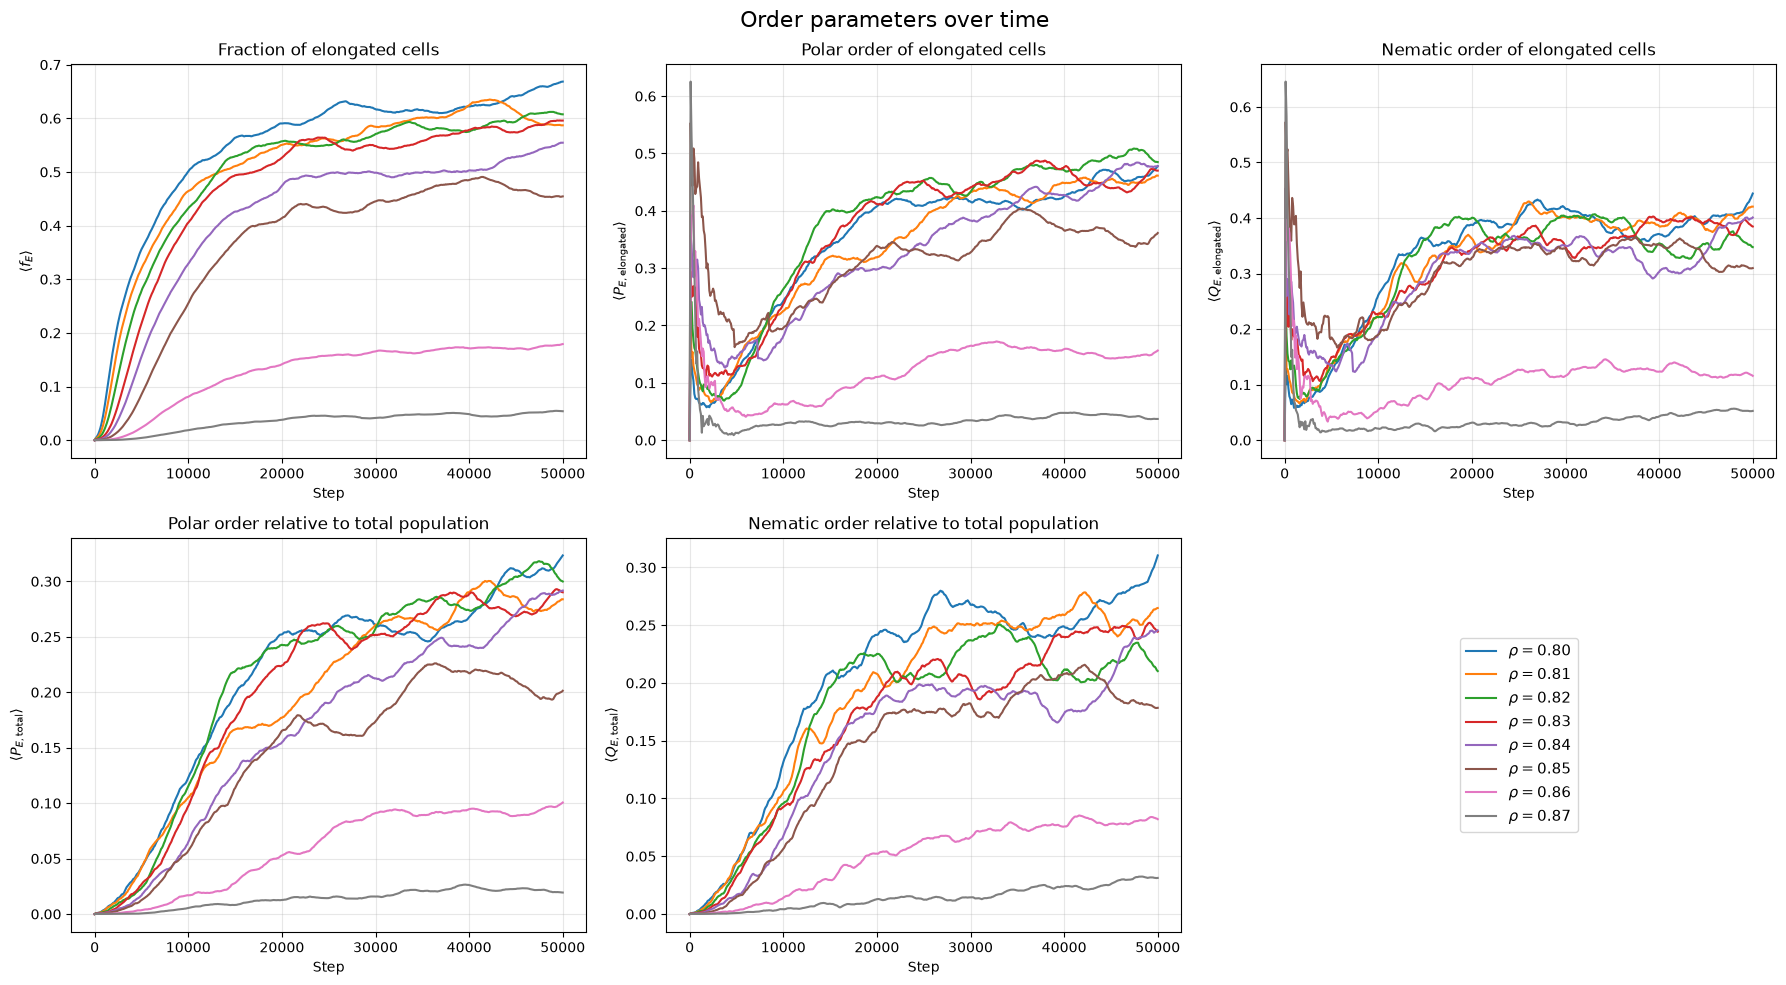

In [12]:
# Plot the order parameters over time for different densities
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Define the observables to plot, along with their labels and titles
observables = [
    ("f_E_mean", r"$\langle f_E \rangle$", "Fraction of elongated cells"),
    (
        "P_E_elongated_mean",
        r"$\langle P_{E,\mathrm{elongated}} \rangle$",
        "Polar order of elongated cells",
    ),
    (
        "Q_E_elongated_mean",
        r"$\langle Q_{E,\mathrm{elongated}} \rangle$",
        "Nematic order of elongated cells",
    ),
    (
        "P_E_total_mean",
        r"$\langle P_{E,\mathrm{total}} \rangle$",
        "Polar order relative to total population",
    ),
    (
        "Q_E_total_mean",
        r"$\langle Q_{E,\mathrm{total}} \rangle$",
        "Nematic order relative to total population",
    ),
]

axs = axs.flatten()

# For each observable, plot the mean value over time for each density (rho)
for ax, (column, ylabel, title) in zip(axs, observables):

    for rho, df_rho in op_time.groupby("rho"):

        ax.plot(
            df_rho["step"],
            df_rho[column],
            label=fr"$\rho={rho:.2f}$"
        )

    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)

    # ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.grid(alpha=0.3)

# The sixth panel is not used
axs[-1].axis("off")

# Put the legend in the empty panel
handles, labels = axs[0].get_legend_handles_labels()

axs[-1].legend(
    handles,
    labels,
    loc="center",
    fontsize=11,
)

# Plot configuration
graph_title = "Order parameters over time"
fig.suptitle(graph_title, fontsize=16)
rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()
plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

$f_E$ increases progressively from the initially round configuration. For lower densities, a substantial fraction of the population becomes elongated, while the elongated fraction is strongly suppressed at the highest densities. 

$P_{E, total}$ and $Q_{E, total}$ show the same suppression at high density, indicating that collective orientational order becomes macroscopically small when elongation is inhibited.

$P_{E, elongated}$ and $Q_{E, elongated}$ remain finite whenever an elongated subpopulation is present. At very early times, these quantities should be interpreted with caution because $N_E$ is still very small.

## Steady state

To obtain a more stable estimate of the order parameters and compare their dependence on density, we average each observable over the final $10\%$ of each realization. We first perform the temporal average independently for each seed and then average over realizations.

At this stage, the final $10\%$ is used as a late-time averaging window rather than assuming that all realizations have reached a fully stationary state. Longer simulations will be used to assess convergence.

In [13]:
# Fraction of the simulation used as steady state
steady_fraction = 0.10

max_step = op["step"].max()
steady_start = max_step * (1 - steady_fraction)

op_steady = op[
    op["step"] >= steady_start
].copy()

print("Steady-state interval:")
print(op_steady["step"].min(), "-", op_steady["step"].max())

Steady-state interval:
45000 - 50000


In [14]:
# First average over time for each seed
op_seed_stats = (
    op_steady
    .groupby(["N", "rho", "seed"])
    .agg(
        f_E=("f_E", "mean"),
        P_E_elongated=("P_E_elongated", "mean"),
        Q_E_elongated=("Q_E_elongated", "mean"),
        P_E_total=("P_E_total", "mean"),
        Q_E_total=("Q_E_total", "mean"),
    )
    .reset_index()
)

op_seed_stats.head()

,N,rho,seed,f_E,P_E_elongated,Q_E_elongated,P_E_total,Q_E_total
0,10000,0.8,12944511869278,0.745316,0.655767,0.653056,0.490207,0.488748
1,10000,0.8,78804909138230,0.689865,0.769821,0.540560,0.531551,0.373201
2,10000,0.8,170902461924754,0.679954,0.676482,0.359251,0.462203,0.247967
3,10000,0.8,211701226972609,0.697891,0.494102,0.553995,0.344703,0.384880
4,10000,0.8,260045648084392,0.774608,0.711910,0.592580,0.550541,0.458717


In [15]:
# Then average over seeds
op_rho_stats = (
    op_seed_stats
    .groupby(["N", "rho"])
    .agg(
        f_E_mean=("f_E", "mean"),
        f_E_std=("f_E", "std"),

        P_E_elongated_mean=("P_E_elongated", "mean"),
        P_E_elongated_std=("P_E_elongated", "std"),

        Q_E_elongated_mean=("Q_E_elongated", "mean"),
        Q_E_elongated_std=("Q_E_elongated", "std"),

        P_E_total_mean=("P_E_total", "mean"),
        P_E_total_std=("P_E_total", "std"),

        Q_E_total_mean=("Q_E_total", "mean"),
        Q_E_total_std=("Q_E_total", "std"),
    )
    .reset_index()
)

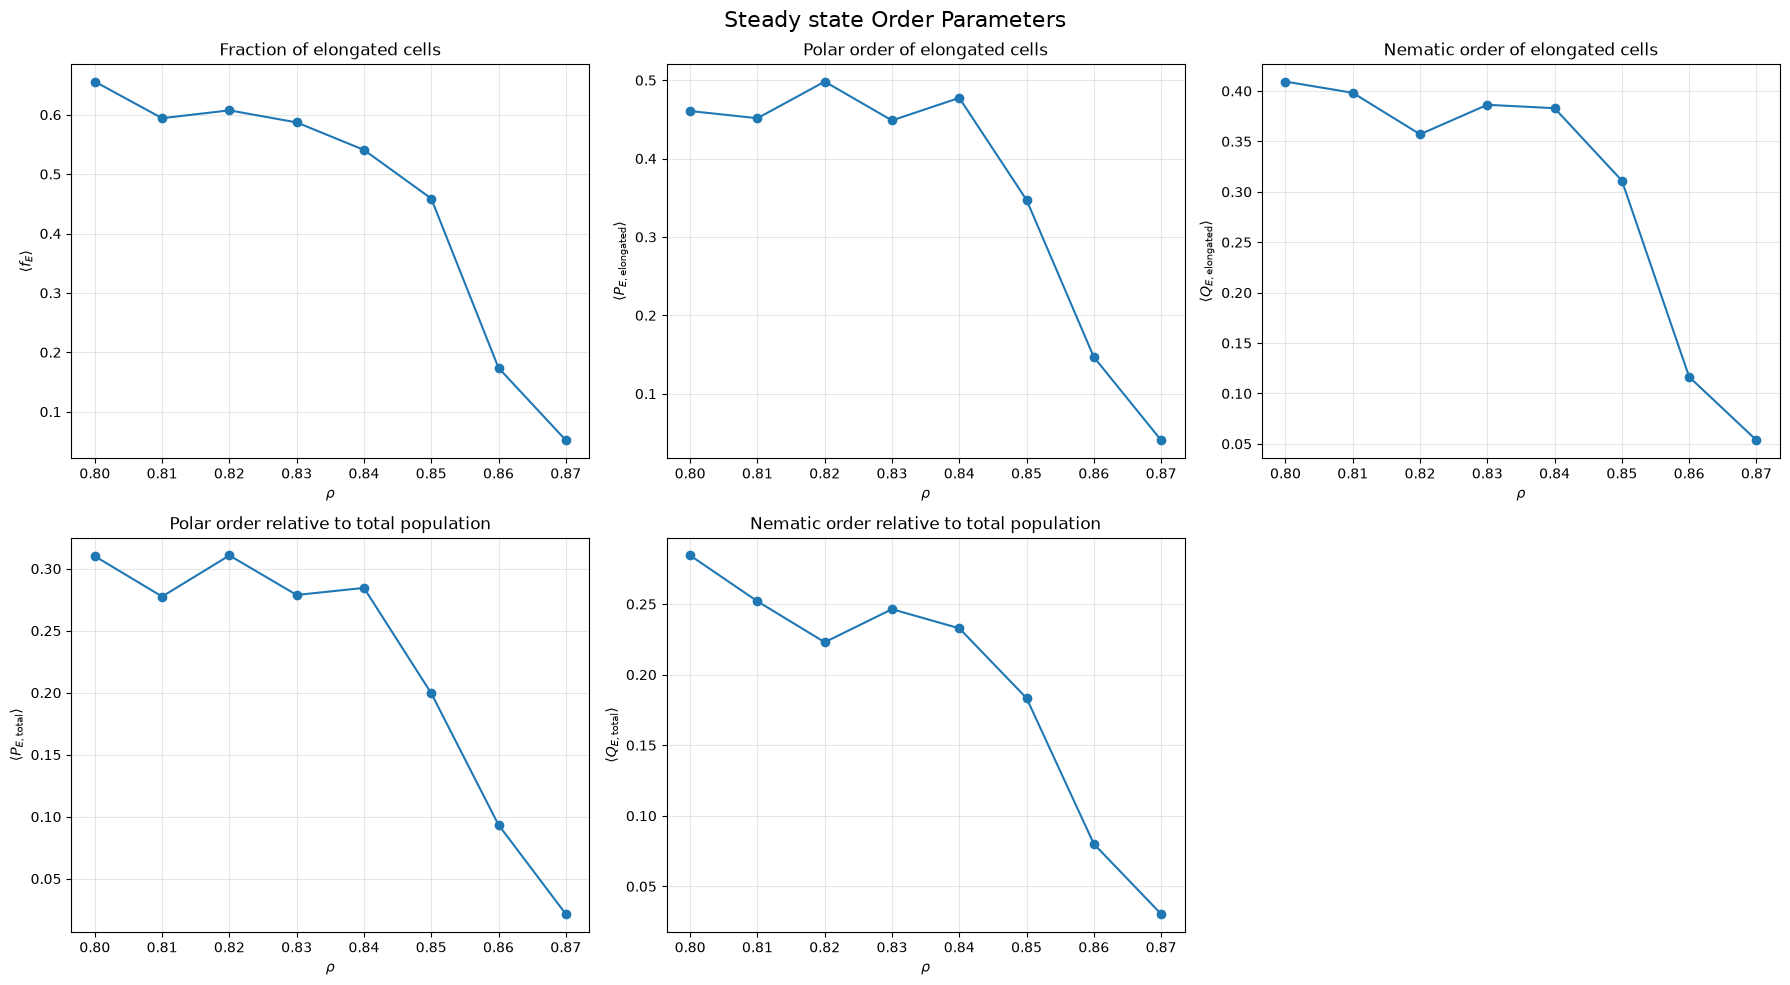

In [16]:
# Plot the order parameters in the steady state for different densities
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Define the observables to plot, along with their labels and titles
observables = [
    ("f_E_mean", r"$\langle f_E \rangle$", "Fraction of elongated cells"),
    (
        "P_E_elongated_mean",
        r"$\langle P_{E,\mathrm{elongated}} \rangle$",
        "Polar order of elongated cells",
    ),
    (
        "Q_E_elongated_mean",
        r"$\langle Q_{E,\mathrm{elongated}} \rangle$",
        "Nematic order of elongated cells",
    ),
    (
        "P_E_total_mean",
        r"$\langle P_{E,\mathrm{total}} \rangle$",
        "Polar order relative to total population",
    ),
    (
        "Q_E_total_mean",
        r"$\langle Q_{E,\mathrm{total}} \rangle$",
        "Nematic order relative to total population",
    ),
]

axs = axs.flatten()

# For each observable, plot the mean value in the steady state for each density (rho)
for ax, (column, ylabel, title) in zip(axs, observables):

    ax.plot(
        op_rho_stats["rho"],
        op_rho_stats[column],
        marker="o",
    )

    ax.set_title(title)
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

axs[-1].axis("off")

# Plot configuration
graph_title = "Steady state Order Parameters"

fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The late-time $f_E$ remains relatively large at lower densities and decreases sharply between $\rho=0.85$ and $\rho=0.86$. A similar decrease is observed for $P_{E, total}$ and $Q_{E, total}$.

Among the quantities considered here, $f_E$ provides the most direct measure of the morphological state of the system and will therefore be used as the primary observable to characterize the transition.

## Susceptibility

To quantify the fluctuations of the elongated fraction, we define its susceptibility as

\begin{equation}
    \chi_{f_E}=N_{actual}​[⟨f_E^{2}​⟩−⟨f_E​⟩^{2}]
\end{equation}

The temporal moments are first evaluated within the late-time window for each realization and are subsequently averaged over seeds.

In [17]:
# Calculate the first and second moments of f_E
op_steady["f_E_squared"] = op_steady["f_E"]**2

# First average over time for each seed
f_E_moments_seed = (
    op_steady
    .groupby(["N", "actual_N", "rho", "seed"])
    .agg(
        f_E_mean=("f_E", "mean"),
        f_E_squared_mean=("f_E_squared", "mean"),
    )
    .reset_index()
)

f_E_moments_seed.head()

,N,actual_N,rho,seed,f_E_mean,f_E_squared_mean
0,10000,9000,0.8,12944511869278,0.745316,0.556318
1,10000,9000,0.8,78804909138230,0.689865,0.476653
2,10000,9000,0.8,170902461924754,0.679954,0.463345
3,10000,9000,0.8,211701226972609,0.697891,0.491693
4,10000,9000,0.8,260045648084392,0.774608,0.600736


In [18]:
# Then average the moments over seeds
f_E_moments = (
    f_E_moments_seed
    .groupby(["N", "actual_N", "rho"])
    .agg(
        f_E_mean=("f_E_mean", "mean"),
        f_E_squared_mean=("f_E_squared_mean", "mean"),
    )
    .reset_index()
)

# Calculate susceptibility
f_E_moments["chi_f_E"] = (
    f_E_moments["actual_N"]
    * (
        f_E_moments["f_E_squared_mean"]
        - f_E_moments["f_E_mean"]**2
    )
)

f_E_moments

,N,actual_N,rho,f_E_mean,f_E_squared_mean,chi_f_E
0,10000,9000,0.80,0.655751,0.451415,192.648115
1,10000,9113,0.81,0.594140,0.374038,191.699381
2,10000,9225,0.82,0.607367,0.382570,126.161253
3,10000,9338,0.83,0.587048,0.369117,228.698309
4,10000,9450,0.84,0.540744,0.326526,322.456207
5,10000,9563,0.85,0.458907,0.262862,499.831081
6,10000,9675,0.86,0.173837,0.110540,777.107426
7,10000,9788,0.87,0.052082,0.029511,262.307620


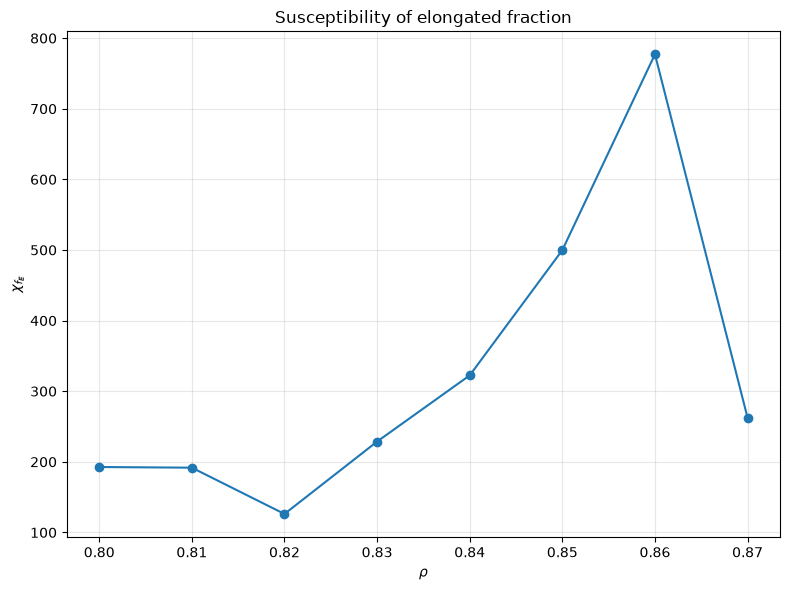

In [19]:
# Plot the susceptibility of the elongated fraction as a function of density
plt.figure(figsize=(8, 6))

plt.plot(
    f_E_moments["rho"],
    f_E_moments["chi_f_E"],
    marker="o"
)

plt.xlabel(r"$\rho$")
plt.ylabel(r"$\chi_{f_E}$")

plt.grid(alpha=0.3)

graph_title = "Susceptibility of elongated fraction"

plt.title(graph_title)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

For $N=10000$, the susceptibility displays a pronounced maximum at $\rho=0.86$, coinciding with the region where the late-time elongated fraction decreases sharply. We therefore use the susceptibility maximum as a reference point to inspect the fluctuations and the distribution of $f_E$ near the transition.

We can also get the density associated to the susceptibility peak and the value of the susceptibility.

In [20]:
peak_index = f_E_moments["chi_f_E"].idxmax()

rho_peak = f_E_moments.loc[peak_index, "rho"]
chi_peak = f_E_moments.loc[peak_index, "chi_f_E"]

print(f"Susceptibility peak at rho = {rho_peak:.3f}")
print(f"chi_max = {chi_peak:.6f}")

Susceptibility peak at rho = 0.860
chi_max = 777.107426


## Elongated-fraction distributions near the susceptibility peak

To investigate the origin of the enhanced fluctuations, we examine the distribution of the late-time averaged elongated fraction, $\langle f_E \rangle _t$, across independent realizations. We consider the density corresponding to the susceptibility maximum together with the immediately neighboring sampled densities.

In [21]:
# Find the susceptibility peak
peak_index = f_E_moments["chi_f_E"].idxmax()
rho_peak = f_E_moments.loc[peak_index, "rho"]

# Get the sampled density immediately below, at, and above the peak
rho_values = np.sort(op_seed_stats["rho"].unique())

peak_position = np.where(
    np.isclose(rho_values, rho_peak)
)[0][0]

rho_near_peak = rho_values[
    max(0, peak_position - 1):
    min(len(rho_values), peak_position + 2)
]

print("Susceptibility peak:", rho_peak)
print("Densities used:", rho_near_peak)

Susceptibility peak: 0.86
Densities used: [0.85 0.86 0.87]


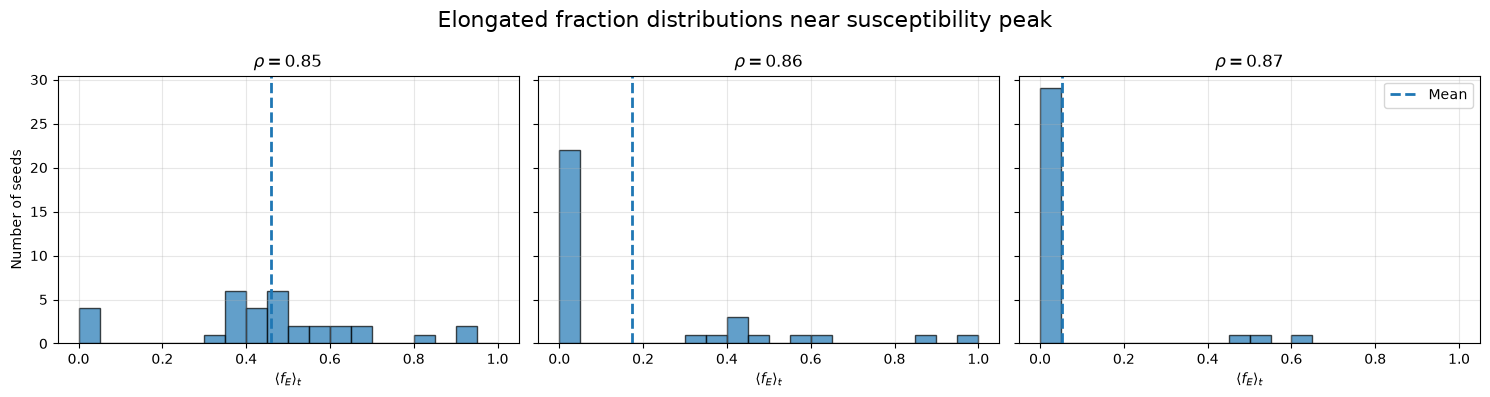

In [22]:
# Plot the distributions of f_E for densities near the susceptibility peak
bins = np.linspace(0, 1, 21)

fig, axs = plt.subplots(
    1,
    len(rho_near_peak),
    figsize=(15, 4),
    sharex=True,
    sharey=True,
)

# For each density near the susceptibility peak, plot the histogram of f_E values across seeds
for ax, rho in zip(axs, rho_near_peak):

    data = op_seed_stats[
        np.isclose(op_seed_stats["rho"], rho)
    ]["f_E"]

    ax.hist(
        data,
        bins=bins,
        edgecolor="black",
        alpha=0.7,
    )

    ax.axvline(
        data.mean(),
        linestyle="--",
        linewidth=2,
        label="Mean",
    )

    ax.set_title(fr"$\rho={rho:.2f}$")
    ax.set_xlabel(r"$\langle f_E\rangle_t$")
    ax.grid(alpha=0.3)

axs[0].set_ylabel("Number of seeds")
axs[-1].legend()

graph_title = "Elongated fraction distributions near susceptibility peak"
fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

At $\rho=0.85$, most realizations retain a substantial elongated population, although realizations with very small $f_E$ are already present. At $\rho=0.86$, realizations with $f_E \approx 0$ coexist with others retaining a finite elongated fraction. At $\rho=0.87$, most realizations belong to the low- $f_E$ branch, while a small number remain strongly elongated.

## Individual realizations near the susceptibility peak

To determine whether the broad distribution near the susceptibility maximum originates from distinct dynamical behaviors, we inspect the time evolution of $f_E$ for each independent realization at $\rho=0.86$.

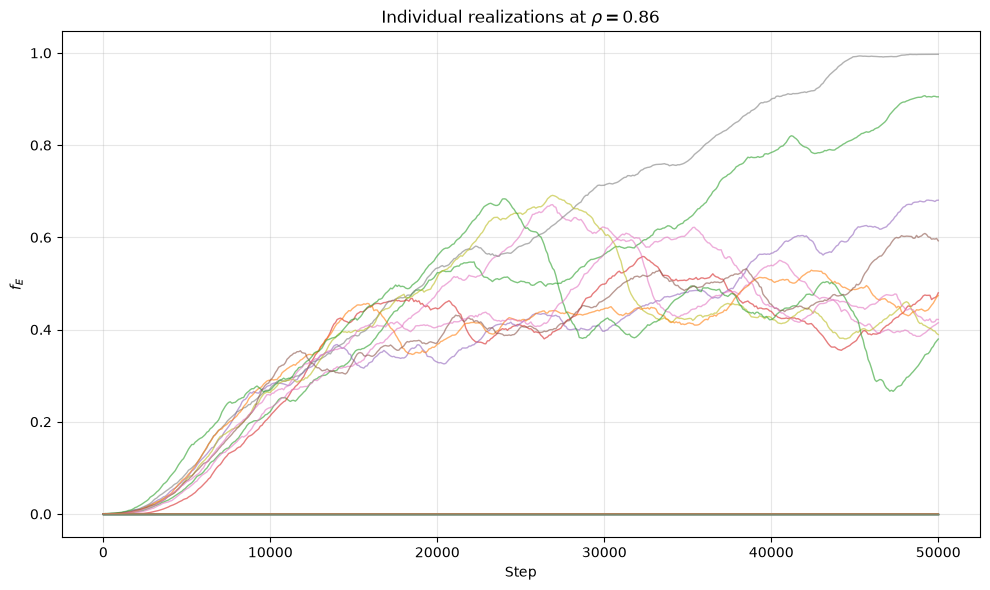

In [23]:
# Plot the time evolution of f_E for individual seeds at the susceptibility peak density
rho_selected = rho_peak

df_peak = op[
    np.isclose(op["rho"], rho_selected)
]

plt.figure(figsize=(10, 6))

for seed, df_seed in df_peak.groupby("seed"):

    plt.plot(
        df_seed["step"],
        df_seed["f_E"],
        alpha=0.6,
        linewidth=1,
    )

plt.xlabel("Step")
plt.ylabel(r"$f_E$")

plt.title(
    fr"Individual realizations at $\rho={rho_selected:.2f}$"
)

plt.grid(alpha=0.3)

graph_title = (
    f"elongated_fraction_individual_seeds_rho_{rho_selected:.2f}"
)

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{graph_title}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The individual trajectories show a strong separation between realizations. Several remain close to the fully round state, whereas others develop and retain a substantial elongated population.